In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torch.nn.functional as F
from torch.optim.lr_scheduler import LambdaLR

import torchvision.transforms.functional as TF
from PIL import Image
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
# 自定義資料集類別
class MiniImageNetDataset(Dataset):
    def __init__(self, txt_file, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.data = []
        
        # 讀取txt檔案中的路徑和標籤
        with open(txt_file, 'r') as f:
            for line in f:
                img_path, label = line.strip().split()
                self.data.append((img_path, int(label)))
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        img_path, label = self.data[idx]
        # 設定完整路徑
        full_path = os.path.join(self.root_dir, img_path)
        
        # 讀取原始圖片
        img = Image.open(full_path).convert('RGB')
        
        if self.transform:
            img = self.transform(img)
            
        return img, label

# 資料預處理函數
def get_transforms():
    # 訓練集的轉換
    train_transform = transforms.Compose([
        transforms.RandomResizedCrop(224),  # ResNet34預設輸入尺寸為224x224
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # 驗證集的轉換
    val_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    return train_transform, val_transform

# 載入資料集函數
def load_datasets(root_dir, txt_dir, train_transform, val_transform, batch_size=64):
    # 創建訓練集
    train_dataset = MiniImageNetDataset(
        txt_file=os.path.join(txt_dir, 'train.txt'),
        root_dir=root_dir,
        transform=train_transform
    )
    
    # 創建驗證集
    val_dataset = MiniImageNetDataset(
        txt_file=os.path.join(txt_dir, 'val.txt'),
        root_dir=root_dir,
        transform=val_transform
    )
    
    # 創建資料加載器
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
    
    return train_loader, val_loader

In [3]:
# 載入或創建 ResNet34 模型
def create_resnet34_model(num_classes=100, pretrained=False):
    # 載入 ResNet34 模型
    model = models.resnet34(pretrained=pretrained)
    
    # 修改最後一層以適應我們的類別數
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    
    return model

# 訓練函數
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in tqdm(train_loader, desc="Training"):
        inputs, labels = inputs.to(device), labels.to(device)
        
        # 清除梯度
        optimizer.zero_grad()
        
        # 前向傳播
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # 反向傳播和優化
        loss.backward()
        optimizer.step()
        
        # 累計統計
        running_loss += loss.item() * inputs.size(0)
        
        # 計算準確率
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc

# 驗證函數
def validate(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc="Validating"):
            inputs, labels = inputs.to(device), labels.to(device)
            
            # 前向傳播
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            # 累計統計
            running_loss += loss.item() * inputs.size(0)
            
            # 計算準確率
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc

# 保存檢查點的函數
def save_checkpoint(model, optimizer, epoch, filename="checkpoint.pth"):
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
    }
    torch.save(checkpoint, filename)
    print(f"Checkpoint saved to {filename}")

# 繪製訓練曲線的函數
def plot_training_curves(train_losses, train_accs, val_losses, val_accs, save_path="training_curves.png"):
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train')
    plt.plot(val_losses, label='Val')
    plt.title('Loss vs. Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label='Train')
    plt.plot(val_accs, label='Val')
    plt.title('Accuracy vs. Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()

In [4]:
# 完整的訓練和驗證流程
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, device, 
                num_epochs=30, checkpoint_dir="checkpoints", save_best=True):
    # 創建檢查點目錄
    os.makedirs(checkpoint_dir, exist_ok=True)
    
    best_val_acc = 0.0
    train_losses, train_accs = [], []
    val_losses, val_accs = [], []
    
    start_time = time.time()
    
    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        
        # 訓練一個 epoch
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        
        # 驗證
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        
        # 更新學習率
        if scheduler is not None:
            scheduler.step(val_loss)  # 如果使用 ReduceLROnPlateau
        
        # 輸出當前結果
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
        
        # 保存最佳模型
        if save_best and val_acc > best_val_acc:
            best_val_acc = val_acc
            save_checkpoint(model, optimizer, epoch, 
                          filename=f"{checkpoint_dir}/best_model.pth")
        
        # 定期保存檢查點
        if (epoch + 1) % 5 == 0:
            save_checkpoint(model, optimizer, epoch, 
                          filename=f"{checkpoint_dir}/epoch_{epoch+1}.pth")
    
    # 計算訓練時間
    time_elapsed = time.time() - start_time
    print(f"Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
    print(f"Best val Acc: {best_val_acc:.4f}")
    
    # 繪製訓練曲線
    plot_training_curves(train_losses, train_accs, val_losses, val_accs,
                        save_path=f"{checkpoint_dir}/training_curves.png")
    
    return model, best_val_acc, (train_losses, train_accs, val_losses, val_accs)

Using device: cuda


/home/harry/miniconda3/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/harry/miniconda3/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Epoch 1/15


Validating: 100%|██████████| 8/8 [00:01<00:00,  6.49it/s]


Train Loss: 3.5632, Train Acc: 0.0953
Val Loss: 3.1353, Val Acc: 0.1511
Checkpoint saved to Taskb_checkpoints/best_model.pth
Epoch 2/15


...

Train Loss: 1.5434, Train Acc: 0.5451
Val Loss: 1.2326, Val Acc: 0.6156
Epoch 14/15


Validating: 100%|██████████| 8/8 [00:00<00:00,  8.62it/s]


Train Loss: 1.4953, Train Acc: 0.5579
Val Loss: 1.1824, Val Acc: 0.6511
Checkpoint saved to Taskb_checkpoints/best_model.pth
Epoch 15/15


Validating: 100%|██████████| 8/8 [00:00<00:00, 11.22it/s]


Train Loss: 1.4470, Train Acc: 0.5711
Val Loss: 1.2812, Val Acc: 0.6000
Checkpoint saved to Taskb_checkpoints/epoch_15.pth
Training complete in 50m 53s
Best val Acc: 0.6511


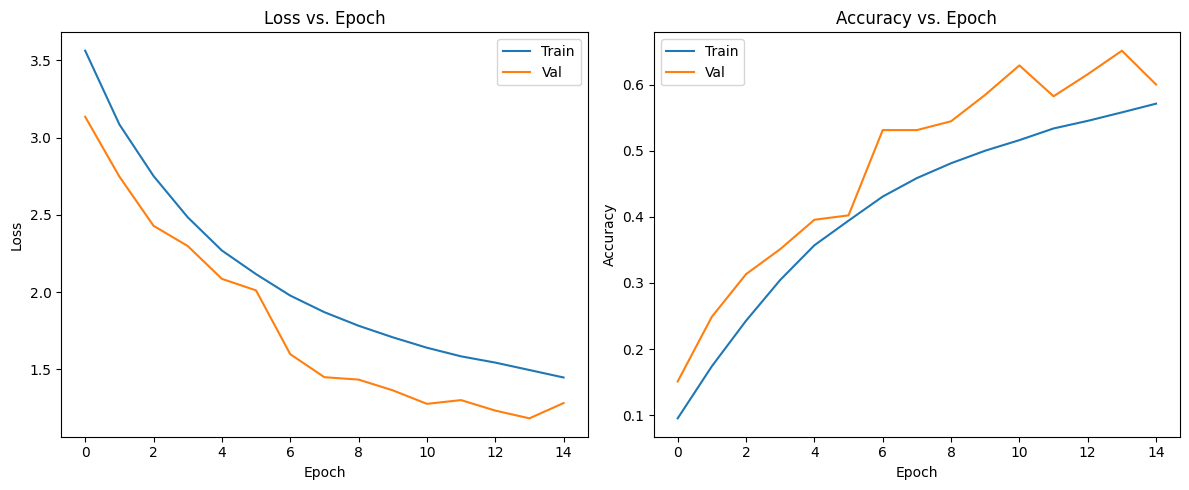

Training completed with best validation accuracy: 0.6511


In [5]:
torch.manual_seed(42)
np.random.seed(42)

# 設定設備（GPU或CPU）
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 定義數據路徑
root_dir = 'dataset'  # 基於HW1下的dataset資料夾
txt_dir = 'dataset'   # txt檔案所在資料夾

# 獲取數據轉換
train_transform, val_transform = get_transforms()

# 載入數據
batch_size = 64  # 根據你的GPU記憶體調整
train_loader, val_loader = load_datasets(root_dir, txt_dir, train_transform, val_transform, batch_size)

# 創建模型
model = create_resnet34_model(num_classes=100, pretrained=False)
model = model.to(device)

# 定義損失函數和優化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)

# 學習率調整策略
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

# 開始訓練
model, best_val_acc, history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    num_epochs=15,
    checkpoint_dir="Taskb_checkpoints",
    save_best=True
)

print(f"Training completed with best validation accuracy: {best_val_acc:.4f}")

-----------------------------